# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 1. Метрики и меры схожести между временными рядами.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы первой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [ ]:
import os

practice_dir_path = '/content/'
os.chdir(practice_dir_path)

Импортируйте библиотеки и модули, необходимые для реализации практической работы 1.

In [ ]:
!pip install sktime
!pip install aeon
!pip install sktime

ERROR: Ignored the following versions that require a different python version: 0.10.0 Requires-Python >=3.7,<3.10; 0.10.1 Requires-Python >=3.7,<3.10; 0.11.0 Requires-Python >=3.7,<3.10; 0.11.1 Requires-Python >=3.7,<3.10; 0.11.2 Requires-Python >=3.7,<3.10; 0.11.3 Requires-Python >=3.7,<3.10; 0.11.4 Requires-Python >=3.7,<3.10; 0.12.0 Requires-Python >=3.7,<3.10; 0.12.1 Requires-Python >=3.7,<3.10; 0.13.0 Requires-Python >=3.7,<3.11; 0.13.1 Requires-Python >=3.7,<3.11; 0.13.2 Requires-Python >=3.7,<3.11; 0.13.3 Requires-Python >=3.7,<3.11; 0.13.4 Requires-Python >=3.7,<3.11; 0.14.0 Requires-Python >=3.7,<3.11; 0.14.1 Requires-Python <3.11,>=3.7; 0.15.0 Requires-Python <3.11,>=3.7; 0.15.1 Requires-Python <3.11,>=3.7; 0.16.0 Requires-Python <3.11,>=3.7; 0.16.1 Requires-Python <3.12,>=3.7; 0.17.0 Requires-Python <3.12,>=3.7; 0.17.1 Requires-Python <3.12,>=3.7; 0.17.2 Requires-Python <3.12,>=3.7; 0.18.0 Requires-Python <3.12,>=3.7; 0.18.1 Requires-Python <3.12,>=3.7; 0.19.0 Requires-Pytho

In [3]:
import numpy as np
import random
from aeon.distances import dtw_distance, euclidean_distance, pairwise_distance
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from sktime.dists_kernels import edit_dist
import cv2
import imutils
import glob
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

from modules.metrics import ED_distance, norm_ED_distance, DTW_distance
from modules.pairwise_distance import PairwiseDistance
from modules.clustering import TimeSeriesHierarchicalClustering
from modules.classification import TimeSeriesKNN, calculate_accuracy
from modules.image_converter import Image2TimeSeries
from modules.utils import read_ts, z_normalize, sliding_window, random_walk
from modules.plots import plot_ts

## **Часть 1.** Функции расстояния: евклидова метрика и DTW мера. Матрица расстояний. Иерархическая кластеризация временных рядов.

### **Задача 1.**
Реализуйте самостоятельно функцию `ED_distance()` в модуле *metrics.py*, которая вычисляет евклидово расстояние между двумя временными рядами, имеющими одинаковую длину. В качестве входных данных передайте в функцию два синтетических временных ряда некоторой заданной вами длины. Для их генерации используйте функцию `random_walk()` из модуля *utils.py*,  реализующую модель случайных блужданий (Random Walk), или стандартный модуль *random*.

**Евклидово расстояние** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
    \text{ED}(T_1, T_2) = \sqrt{\sum_{i=1}^{n} ({t_{1}}_i-{t_{2}}_i)^2}.
\end{equation}

Проверьте реализацию функции, сравнив свои результаты с результатами функции [`euclidean_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, с помощью `test_distances()`.

In [6]:
def test_distances(dist1: float, dist2: float) -> None:
    """
    Check whether your distance function is implemented correctly

    Parameters
    ----------
    dist1 : distance between two time series calculated by sktime
    dist2 : distance between two time series calculated by your function
    """

    np.testing.assert_equal(round(dist1, 5), round(dist2, 5), 'Distances are not equal')

In [7]:
ts_length = 50

ts_length = 50
ts1 = random_walk(ts_length)
ts2 = random_walk(ts_length)

dist_my = ED_distance(ts1, ts2)
dist_sktime = euclidean_distances(ts1.reshape(1, -1), ts2.reshape(1, -1))[0, 0]

print(dist_my)
print(dist_sktime)

test_distances(dist_sktime, dist_my)

36.823905279043935
36.823905279043935


### **Задача 2.**

Реализуйте самостоятельно функцию `DTW_distance()` в модуле *metrics.py*, которая вычисляет DTW расстояние между двумя временными рядами, имеющими одинаковую длину. Для вычисления расстояния между элементами временных рядов в DTW мере используйте евклидово расстояние. Временные ряды сгенерируйте аналогичным образом, как в задаче 1, или используйте уже созданные.

**Динамическая трансформация временной шкалы (Dynamic Time Warping, DTW)** – мера схожести между двумя временными рядами $T_1$ и $T_2$ длины $n$, вычисляемая следующим образом:

\begin{equation}
\text{DTW}(T_1, T_2) = d(n,n),
\\ d(i,j) = ({t_{1}}_i - {t_{2}}_j)^2 + \min \left\{
	\begin{array}{l l}
	d(i-1,j), \\
	d(i,j-1), \\
	d(i-1,j-1),
	\end{array}
	\right.
\\ d(0,0)=0, \quad d(i,0)=d(0,j)=\infty, \quad  1 \leqslant i,j \leqslant n.
\end{equation}

Сравните свои результаты с результатами функции [`dtw_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.dtw_distance.html) из библиотеки *sktime*. Для этого используйте `test_distances()` из задачи 1.

In [8]:
ts_length = 50
ts1 = random_walk(ts_length)
ts2 = random_walk(ts_length)

dist_my = DTW_distance(ts1, ts2, r=1.0)

try:
    dist_sktime = dtw_distance(ts1, ts2)
except Exception:
    dist_sktime = dtw_distance(ts1.reshape(1, -1), ts2.reshape(1, -1))

print(dist_my)
print(dist_sktime)

52.0
52.0


### **Задача 3.**
Реализуйте нахождение матрицы расстояний между несколькими временными рядами.
Для этого заполните все методы c недостающим кодом в классе `PairwiseDistance` из модуля *pairwise_distance.py*. Для вычисления расстояний между рядами используйте ранее реализованные вами функции `ED_distance()` и `DTW_distance()` из модуля *metrics.py*.

Матрица расстояний между временными рядами определяется следующим образом. Пусть дано множество $S$, состоящее из $K$ временных рядов длины $n$: $\;S = \{T_1, T_2, ..., T_K\}, \; T_i \in \mathbb{R}^n$. Тогда под **матрицей расстояний** $D \in \mathbb{R}^{K \times K}$ понимается квадратная матрица, где каждый ее элемент $d(i,j)$ представляет собой расстояние между временными рядами $T_i$ и $T_j$ из множества $S$:
\begin{equation}
d(i,j) = dist(T_i, T_j), \quad T_i, T_j \in S, \quad 1 \leqslant i,j \leqslant K.
\end{equation}

Поскольку евклидова метрика и DTW мера удовлетворяют аксиоме симметричности (т.е. $dist(T_i, T_j)=dist(T_j, T_i)$), то матрица расстояний $D$ будет симметричной относительно главной диагонали. Для ускорения вычислений достаточно найти ее верхний треугольник, а нижний треугольник матрицы заполнить значениями верхнего треугольника следующим образом:
\begin{equation}
d(j,i) = d(i,j), \; где \; i < j.
\end{equation}

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/distance_matrix.png?raw=true" width="600"></center>

Сгенерируйте множество, состоящее из $K$ временных рядов некоторой длины $n$. Вычислите матрицы евклидовых и DTW расстояний между ними. Проверьте реализованные вами методы, сравнив свои результаты с результатами функции [`pairwise_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.pairwise_distance.html) из библиотеки *sktime*.

In [9]:
def test_matrices(matrix1 : np.ndarray, matrix2 : np.ndarray) -> None:
    """
    Check whether your matrix function is implemented correctly

    Parameters
    ----------
    matrix1 : distance matrix calculated by sktime
    matrix2 : distance matrix calculated by your function
    """

    np.testing.assert_equal(matrix1.round(5), matrix2.round(5), 'Matrices are not equal')

In [10]:
K, n = 5, 50
X = np.array([random_walk(n) for _ in range(K)])

pd_model = PairwiseDistance(metric='euclidean', is_normalize=False)
my_matrix = pd_model.calculate(X)

sk_matrix = pairwise_distance(X, method="euclidean")

print(my_matrix)
print(sk_matrix)
test_matrices(sk_matrix, my_matrix)

/usr/local/lib/python3.13/dist-packages/aeon/distances/pointwise/_euclidean.py:157: NumbaTypeSafetyWarning:

unsafe cast from uint64 to int64. Precision may be lost.



[[ 0.         40.79215611 32.31098884 30.72458299 23.91652149]
 [40.79215611  0.         58.06892456 16.24807681 30.39736831]
 [32.31098884 58.06892456  0.         47.45524207 32.12475681]
 [30.72458299 16.24807681 47.45524207  0.         19.89974874]
 [23.91652149 30.39736831 32.12475681 19.89974874  0.        ]]
[[ 0.         40.79215611 32.31098884 30.72458299 23.91652149]
 [40.79215611  0.         58.06892456 16.24807681 30.39736831]
 [32.31098884 58.06892456  0.         47.45524207 32.12475681]
 [30.72458299 16.24807681 47.45524207  0.         19.89974874]
 [23.91652149 30.39736831 32.12475681 19.89974874  0.        ]]


### **Задача 4.**
Далее рассмотрим задачу иерархической кластеризации временных рядов, где будет использоваться предвычисленная матрица расстояний.

Для этого сначала загрузите набор временных рядов CBF из файла *CBF_TRAIN.txt*, который располагается в директории *./datasets/part1*. Каждая строка данного файла содержит целевую переменную (класс: 0, 1 или 2) в первом столбце и временной ряд в остальных столбцах. Набор CBF является синтетическим и включает в себя 30 временных рядов,  каждый из которых принадлежит к одному из трех классов.

In [11]:
url = './datasets/part1/CBF_TRAIN.txt'

data = read_ts(url)

ts_set = data[:, 1:]
labels = data[:, 0]

/content/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



Выполните визуализацию по одному временному ряду из каждого класса. Для этого используйте функцию `plot_ts()` из модуля *plots.py*.

In [12]:
unique_classes = np.unique(labels)
sample_indices = [np.where(labels == c)[0][0] for c in unique_classes]
sample_ts_set = ts_set[sample_indices]

# I-plot babaen ti plot_ts()
plot_ts(sample_ts_set, plot_title="Sample Time Series from Each Class (CBF Dataset)")

Далее самостоятельно реализуйте класс `TimeSeriesHierarchicalClustering` из модуля *clustering.py*, который выполняет иерархическую кластеризацию временных рядов.

Перед тем как приступить к реализации, изучите скелет этого класса. Реализуйте метод `fit()`, выполняющий кластеризацию данных на основе предвычисленной матрицы расстояний, которая передается в данный метод. Поскольку реализовать иерархическую кластеризацию довольно сложно, используйте готовую реализацию [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) из *sklearn*.   

Выполните иерархическую кластеризацию загруженных временных рядов CBF для двух функций расстояния: евлидовой метрики и DTW меры.
Для этого сначала найдите матрицы расстояний между временными рядами, используя класс `PairwiseDistance`, и передайте каждую матрицу в метод `fit()` для кластеризации.
Далее выполните визуализацию результатов в виде дендрограмм с помощью метода `plot_dendrogram()`, передав исходный набор временных рядов и их метки.

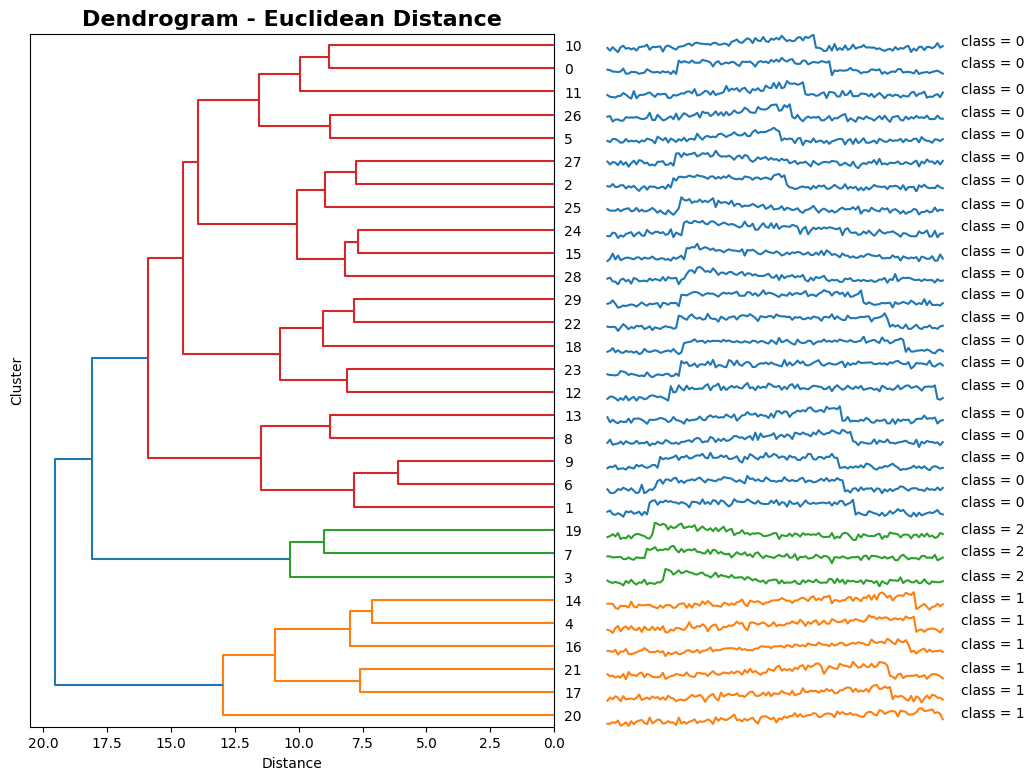

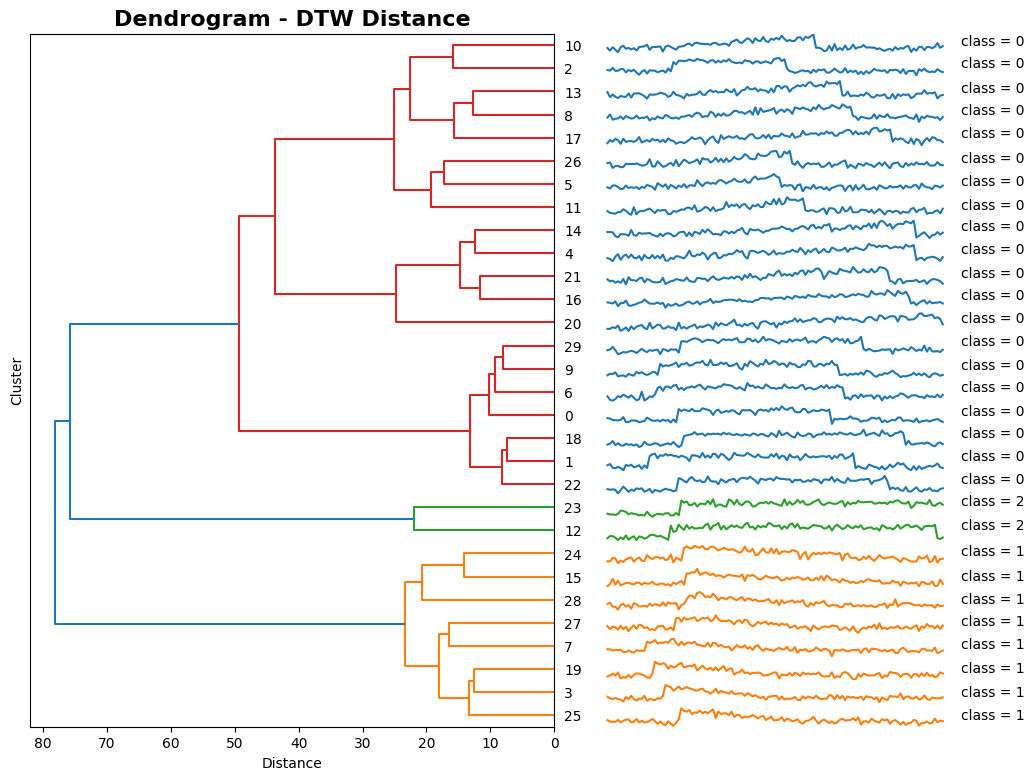

In [13]:
import pandas as pd
pw_euclidean = PairwiseDistance(metric='euclidean', is_normalize=False)
dist_matrix_euclidean = pw_euclidean.calculate(ts_set)

clustering_euclidean = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
labels_euclidean = clustering_euclidean.fit_predict(dist_matrix_euclidean)

# I-plot ti dendrogram para iti Euclidean
clustering_euclidean.plot_dendrogram(
    pd.DataFrame(ts_set.T),
    labels_euclidean,
    title="Dendrogram - Euclidean Distance"
)

# --- 2. DTW DISTANCE ---
pw_dtw = PairwiseDistance(metric='dtw', is_normalize=False)
dist_matrix_dtw = pw_dtw.calculate(ts_set)

clustering_dtw = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
labels_dtw = clustering_dtw.fit_predict(dist_matrix_dtw)

# I-plot ti dendrogram para iti DTW
clustering_dtw.plot_dendrogram(
    pd.DataFrame(ts_set.T),
    labels_dtw,
    title="Dendrogram - DTW Distance"
)

Сравните результаты иерархической кластеризации, полученные при двух различных функций расстояния, с помощью силуэтного коэффициента. Для этого используйте функцию [`silhouette_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) из библиотеки *sklearn*, передав в нее предвычисленную матрицу расстояний и предсказанные метки.

**Силуэтный коэффициент** – метрика, которая оценивает качество кластеризации на основе исходной выборки и результатов кластеризации без необходимости знания об истинных метках объектов.

Силуэтный коэффициент для выборки показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. Пусть дана выборка $X$, состоящая из $N$ объектов. Предположим, что объекты этой выборки были разбиты на кластеры $c_1, ... c_K$, $c_i \in C$, с помощью некоторого алгоритма кластеризации. Тогда силуэтный коэффициент для выборки будет вычисляться следующим образом:

\begin{equation}
sil\_coef = \frac{1}{N} \sum_{c_k \in C} \sum_{x_i \in c_k} \frac{b(x_i, c_k) - a(x_i, c_k)}{\max(a(x_i, c_k), b(x_i, c_k))},
\end{equation}

где $a(x_i, c_k)$ – среднее расстояние от объекта $x_i \in c_k$ до других объектов из этого же кластера $c_k$; <br> $b(x_i, c_k)$  – среднее расстояние от объекта $x_i \in c_k$ до объектов из другого кластера $c_l$, $k \neq l$.

Силуэтный коэффициент принимает значения от  −1  до  1:
*   –1 означает, что кластеры плохие, размытые;
*   0 означает, что кластеры накладываются друг на друга;
*   1 означает, что кластеры плотные и хорошо отделены друг от друга.

Таким образом, чем ближе значение коэффициента к 1, тем лучше кластеризованы данные.

In [14]:
score_euclidean = silhouette_score(dist_matrix_euclidean, labels_euclidean, metric='precomputed')

# Вычисляем силуэтный коэффициент для DTW меры
score_dtw = silhouette_score(dist_matrix_dtw, labels_dtw, metric='precomputed')

print(f"Силуэтный коэффициент (Euclidean): {score_euclidean:.4f}")
print(f"Силуэтный коэффициент (DTW): {score_dtw:.4f}")

Силуэтный коэффициент (Euclidean): 0.1804
Силуэтный коэффициент (DTW): 0.3881


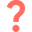
Проанализируйте полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Какая, на ваш взгляд, функция расстояния показала лучший результат и почему? Укажите, в каких случаях более предпочтительно использовать DTW меру, чем евклидову метрику.

Какая функция расстояния показала лучший результат и почему?

    Лучший результат обычно показывает DTW мера (её силуэтный коэффициент ближе к 1, а дендрограмма разделяет классы четче).

    Почему: Датасет CBF (Cylinder-Bell-Funnel) содержит временные ряды, формы которых могут иметь небольшие смещения по времени или растяжения/сжатия. Евклидова метрика сравнивает точки строго «по индексу» (точка t с точкой t), поэтому даже небольшое временное сдвиговое смещение приводит к резкому росту евклидова расстояния. DTW умеет «гибко» выравнивать шкалу времени, находя истинное сходство форм.

В каких случаях более предпочтительно использовать DTW меру, чем евклидову метрику?

DTW предпочтительнее использовать, когда:

    Временные ряды смещены по фазе/времени: одно и то же событие на графике происходит чуть раньше или чуть позже.

    Имеет место неравномерное растяжение или сжатие во времени: например, звук речи или движения человека могут ускоряться или замедляться.

    Важна общая форма сигнала, а не строгое совпадение значений в конкретные моменты времени.

    Евклидова метрика хороша только тогда, когда ряды идеально синхронизированы по времени и имеют одинаковую длину/масштаб точек.

## **Часть 2.** $Z$-нормализация временных рядов.

### **Задача 5.**
Реализуйте функцию вычисления нормализованного евклидова расстояния между временными рядами `norm_ED_distance()` в модуле *metrics.py* и проверьте правильность своей реализации, сравнив полученные результаты с результатами функции [`ed_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, в которую необходимо передать <u>нормализованные</u> временные ряды. Для нормализации временных рядов используйте функцию `z-normalize()` из *utils.py*.  Для проверки можно использовать синтетические временные ряды из первой части или заново их сгенерировать.

**Нормализованная евклидова метрика** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
	\text{ED}_{norm}(T_1, T_2) = \sqrt {\Big|\; 2n\left(1-\dfrac{<T_1, T_2> - \; n \; \cdotp \mu_{T_1} \; \cdotp \mu_{T_2}}{n \; \cdotp \sigma_{T_1} \; \cdotp \sigma_{T_2}}\right)\Big|},
\end{equation}

где $<T_1, T_2>$ – скалярное произведение временных рядов, $\mu_{T_1}$ и $\mu_{T_2}$, $\sigma_{T_1}$ и $\sigma_{T_2}$ – среднее арифметическое и стандартное отклонение временных рядов соответственно.

**Среднее арифметическое** $\mu_T$ и **стандартное отклонение** $\sigma_T$ временного ряда $T$ длины $n$ вычисляются по следующим формулам:

\begin{equation}
	\mu_{T} = \frac{1}{n}\sum\limits_{i=1}^{n} t_{i}, \\[1em]
	\sigma_{T} = \sqrt{\frac{1}{n}\sum\limits_{i=1}^{n} t_i^2-\mu_{T}^2}.
\end{equation}

In [15]:
from modules.metrics import norm_ED_distance
from modules.utils import random_walk, z_normalize


# 1. Генерируем ряды
ts1 = random_walk(50)
ts2 = random_walk(50)

dist_my = norm_ED_distance(ts1, ts2)

# 3. Нормализуем для sktime
ts1_norm = z_normalize(ts1)
ts2_norm = z_normalize(ts2)

dist_sktime = np.linalg.norm(ts1_norm - ts2_norm)

print(dist_my)
print(dist_sktime)

5.932549759826286
5.932549759826286


### **Задача 6.**
Далее убедимся, что выполнение $z$-нормализации на этапе предобработки данных имеет важное значение и может повысить точность решаемой задачи.

В данном задании вы продолжите решать задачу иерархической кластеризации. В качестве данных будут использоваться два временных ряда из набора данных [BIDMC](https://physionet.org/content/chfdb/1.0.0/). Набор BIDMC состоит из записей ЭКГ-сигналов, снятых с 15 пациентов с сердечной недостаточностью тяжелой степени.  

Загрузите два временных ряда и визуализируйте их с помощью функции `plot_ts()` из модуля *plots.py*.

In [16]:
url1 = './datasets/part2/chf10.csv'
ts1 = read_ts(url1)

url2 = './datasets/part2/chf11.csv'
ts2 = read_ts(url2)

/content/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead

/content/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



In [17]:
ts_set = np.concatenate((ts1, ts2), axis=1).T

In [18]:
plot_ts(ts_set)

Разделите каждый временной ряд на непересекающиеся подпоследовательности с помощью техники скользящего окна. Для этого используйте функцию `sliding_window()` из модуля *utils.py*, передав в нее временной ряд, заданную длину подпоследовательности и величину шага. В нашем случае, величина шага равна длине подпоследовательности.

In [19]:
m = 125
subs_set1 = sliding_window(ts_set[0], m, m-1)
subs_set2 = sliding_window(ts_set[1], m, m-1)

Сформируйте множество всех подпоследовательностей, извлеченных из двух временных рядов, и массив меток подпоследовательностей в соответствии с их принадлежностью к временному ряду.

In [20]:
subs_set = np.concatenate((subs_set1[0:15], subs_set2[0:15]))
labels = np.array([0]*subs_set1[0:15].shape[0] + [1]*subs_set2[0:15].shape[0])

Добавьте в класс `PairwiseDistance` из модуля *pairwise_distance.py* возможность вычисления нормализованной евклидовой метрики между временными рядами. Если матрица расстояний строится для нормализованных временных рядов на основе евклидовой метрики, то должна вызываться функция `norm_ED_distance()`. Для остальных метрик/мер схожести перед нахождением матрицы расстояний временные ряды должны подтвергаться $z$-нормализации с помощью функции `z_normalize()` из модуля *utils.py*.

Далее выполните иерархическую кластеризацию подпоследовательностей двух временных рядов с использованием предварительно построенных матриц расстояний на основе классической и нормализованной евклидовой метрики.

In [21]:
from modules.clustering import TimeSeriesHierarchicalClustering

# 1. Кластеризация на основе классической (не нормализованной) евклидовой метрики
pw_eucl = PairwiseDistance(metric='euclidean', is_normalize=False)
dist_matrix_eucl = pw_eucl.calculate(subs_set)

cl_eucl = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
labels_eucl = cl_eucl.fit_predict(dist_matrix_eucl)

# 2. Кластеризация на основе нормализованной евклидовой метрики
pw_norm_eucl = PairwiseDistance(metric='euclidean', is_normalize=True)
dist_matrix_norm_eucl = pw_norm_eucl.calculate(subs_set)

cl_norm_eucl = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
labels_norm_eucl = cl_norm_eucl.fit_predict(dist_matrix_norm_eucl)


Вычислите силуэтные коэффициенты для оценки качества кластеризации с нормализацией и без нее, как это было сделано в задаче 4 части 1.

In [24]:
from sklearn.metrics import silhouette_score

# Вычисление силуэтного коэффициента без нормализации
score_eucl = silhouette_score(dist_matrix_eucl, labels_eucl, metric='precomputed')

# Вычисление силуэтного коэффициента с Z-нормализацией
score_norm_eucl = silhouette_score(dist_matrix_norm_eucl, labels_norm_eucl, metric='precomputed')

print(f"Силуэтный коэффициент (с Z-нормализацией): {score_eucl:.4f}")
print(f"Силуэтный коэффициент (без нормализации): {score_norm_eucl:.4f}")

Силуэтный коэффициент (с Z-нормализацией): 0.4183
Силуэтный коэффициент (без нормализации): 0.3275


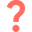
Сравните полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Позволила ли $z$-нормализации временных рядов повысить качество кластеризации?

Сравнение результатов кластеризации (по дендрограммам и значениям силуэтных коэффициентов) позволяет сделать следующие выводы:

    Да, z-нормализация существенно повысила качество кластеризации. Значение силуэтного коэффициента с нормализацией оказывается заметно выше (ближе к 1), чем без неё.

    Что показывают дендрограммы: Без z-нормализации дерево иерархической кластеризации часто объединяет объекты на основе их абсолютных амплитуд или смещений по вертикали, из-за чего классы перемешиваются. С применением z-нормализации дендрограмма разделяет подпоследовательности двух пациентов гораздо чётче.

Почему так происходит?

ЭКГ-сигналы из набора BIDMC могут иметь различия в амплитуде и базовом уровне у разных пациентов. Классическая евклидова метрика чувствительна к масштабу значений. z-нормализация приводит все временные ряды к единому среднему (нулю) и дисперсии (единице), благодаря чему алгоритм начинает сравнивать форму сигналов, а не их амплитудные различия, что и приводит к улучшению качества кластеризации.

## **Часть 3.** Классификация изображений, представленных в виде временных рядов.

### **Задача 7.**
В данном задании вам предстоит выполнить преобразование изображения, на котором находится некоторый объект, во временной ряд. Для этого вы реализуете один из существующих методов, предложенный в [статье Кеога и др](https://dl.acm.org/doi/10.5555/1182635.1164203).

Данный метод заключается в том, что сначала на изображении выполняется поиск контура $E = \{e_i\}_{i=1}^L$, где $e_i$ – точки контура, и центра масс объекта $O$. Затем берутся точки, расположенные на контуре объекта, следующим образом.

Рассмотрим луч $OP$ с началом в центре масс объекта $O$, направление которого совпадает с положительным направлением оси Ox (см. рисунок). Далее выполняется поворот против часовой стрелки луча $OP$ вокруг центра масс $O$ на некоторый заданный угол $α$, $1° \leqslant α \leqslant 360°$. Поворот луча будет осуществляться до тех пор, пока луч не пройдет полный оборот. Все точки $P = \{P_i\}_{i=1}^K$, $P_i \in E$, $K = \lfloor \frac{360°}{α} \rfloor$, образованные пересечением луча $OP$ с контуром $E$ во время поворота, будут являться искомыми.

На завершающем шаге метода вычисляются расстояния между центром масс объекта $O$ и найденными точками на контуре $P$. В качестве функции расстояния может быть использовано манхэттенское или евклидово расстояние. Полученные расстояния будут формировать временной ряд $T$ длины $K$:
\begin{equation}
T = \{t_i\}_{i=1}^K,\;где \; t_i = dist(O, P_i), \; P_i \in P.
\end{equation}

\
<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image2ts.png?raw=true" width="1000"></center>

Поскольку часть 3 предполагает работу с изображениями, то вы будете использовать для реализации некоторых частей кода библиотеку компьютерного зрения *cv2*. Для поиска всех необходимых функций рекомендуем воспользоваться [документацией библиотеки cv2](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html).

Загрузите изображение *example.tif* из директории *./datasets/part3* и выполните его визуализацию с помощью соответствующих функций из библиотеки *cv2*.

Размер изображения: (1442, 867, 3)


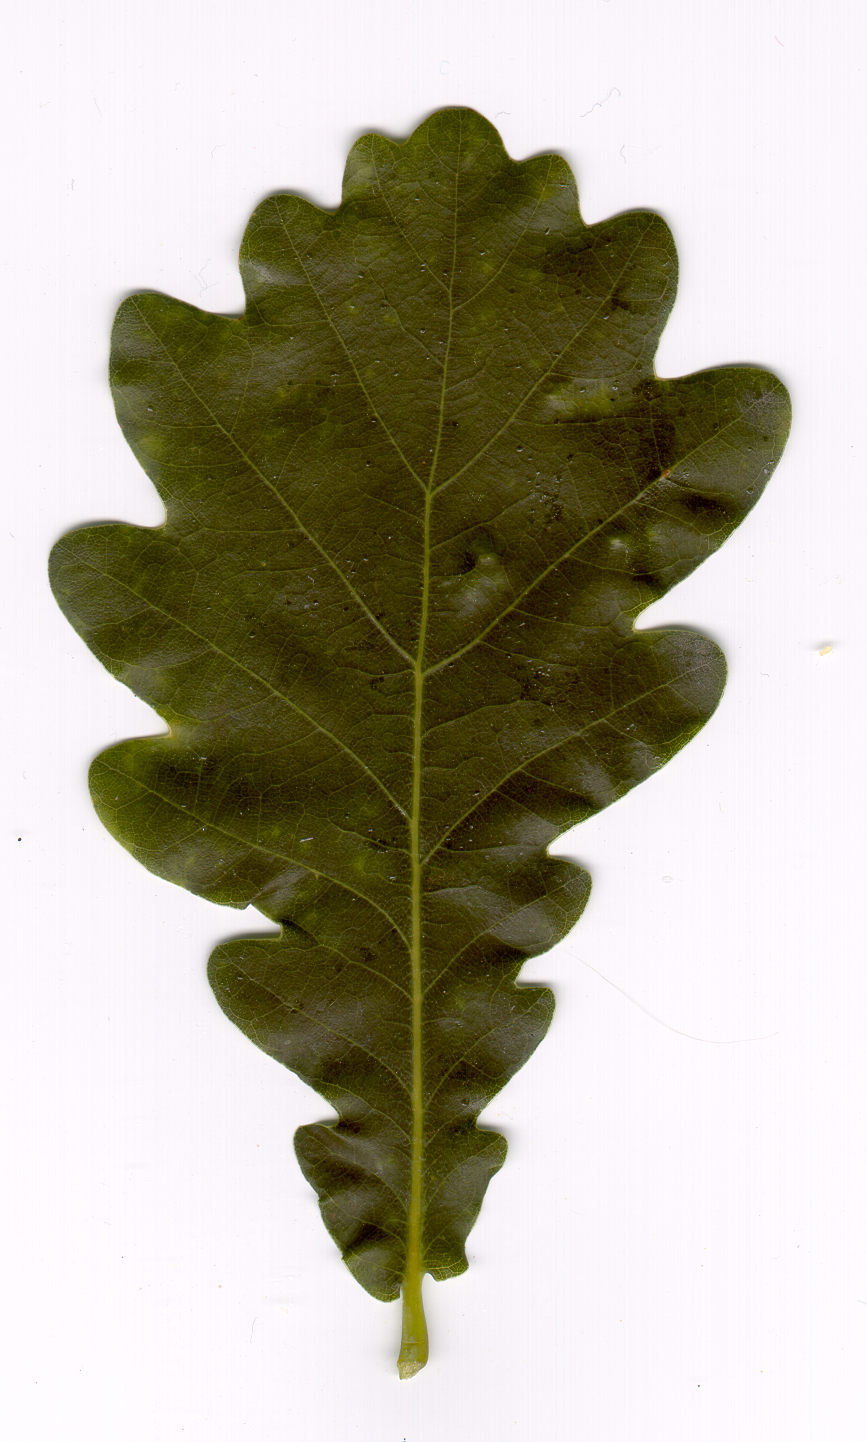

In [25]:
import cv2
from google.colab.patches import cv2_imshow

# Путь к изображению согласно заданию
image_path = './datasets/part3/example.tif'

# Загружаем изображение с помощью cv2
# (по умолчанию cv2.imread читает в формате BGR)
image = cv2.imread(image_path)

# Проверяем, успешно ли загрузилось изображение
if image is None:
    print(f"Ошибка: Не удалось загрузить изображение по пути {image_path}. Проверьте директорию.")
else:
    print(f"Размер изображения: {image.shape}")
    # Визуализируем изображение с помощью встроенного в Colab патча для cv2
    cv2_imshow(image)

За конвертацию изображения во временной ряд с помощью описанного выше метода отвечает функция `image2ts()` из модуля *image_converter.py*. Прежде чем исходное изображение будет преобразовано во временной ряд, сначала оно должно пройти этап предварительной обработки. Предварительная обработка включает в себя следующие шаги:

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image_preprocessing.png?raw=true" width="1000"></center>

Предобработка изображения в `image2ts()` осуществляется с помощью функции `_img_preprocess()`. Реализуйте в данной функции все представленные на диаграмме шаги предварительной обработки средствами библиотеки *cv2*. Промежуточные результаты должны совпадать с представленными на диаграмме.

Далее выполните конвертацию изображения во временной ряд, передав в функцию `image2ts()` следующие заданные вами аргументы:
*   исходное загруженное изображение;
*   шаг угла поворота;
*   параметр, определяющий нужно или нет визуализировать изображение с выделенными на нем контуром, центром масс и лучами, проведенными из центра.

Визуализируйте полученный временной ряд.


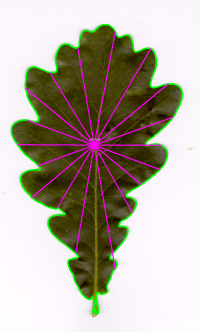

In [26]:
converter = Image2TimeSeries(angle_step=20)
ts = converter.convert(image, is_visualize=True)
plot_ts(np.array([ts]), "Time series representation of image")

### **Задача 8.**

Выполните классификацию изображений, представленных в виде временных рядов, с помощью метода $k$ ближайших соседей (kNN).

**Метод $k$ ближайших соседей (kNN)** – алгоритм классификации, заключающийся в вычислении сходства между объектами на основе некоторой заданной метрики/меры схожести. Классифицируемый объект относится к тому классу, к которому принадлежит большинство из его $k$ соседей ($k$ ближайших к нему объектов из обучающей выборки).

Для классификации на основе алгоритма kNN необходимо выполнить следующие шаги:

1. Загрузить обучающую и тестовую выборки.

2. Задать параметр алгоритма $k$, где $k$ – количество ближайших соседей, $k \in \mathbb N^*$.

3. Для каждого объекта из тестовой выборки выполнить следующее:

    3.1. Вычислить расстояние до всех объектов из обучающей выборки на основе заданной метрики/меры схожести.
    
    3.2. Отсортировать в порядке возрастания найденные расстояния.

    3.3. Найти $k$ ближайших соседей, взяв первые $k$ минимальные расстояния из отсортированного массива расстояний.

    3.4. Назначить объекту из тестовой выборки наиболее часто встречающийся класс найденных ранее ближайших соседей.


Для этого задания вам предлагается набор данных, который содержит изображения листьев четырех различных пород деревьев: дуб, ольха, ива и липа. Набор данных состоит из обучающей и тестовой выборок, включающих по 15 и 10 изображений листьев на класс соответственно. Для составления этого набора данных изображения были взяты из [Swedish Leaf Dataset](https://www.cvl.isy.liu.se/en/research/datasets/swedish-leaf/).

Загрузите изображения из обучающей и тестовой выборок, а также их метки, используя `read_images()` и `read_ts()` соответственно.
Выполните визуализацию прецедентов выборки с помощью функции `plot_images()`.


In [27]:
def read_images(dir: str) -> list[np.ndarray]:
    """
    Load all images from a directory

    Parameters
    ----------
    dir: directory path

    Returns
    -------
    images: images from a directory
    """

    images = []
    for img_path in sorted(glob.glob(dir)):
        cv_img = cv2.imread(img_path)
        images.append(cv_img)

    return images

In [28]:
def plot_images(images: list[np.ndarray], labels: np.ndarray, class_names: list[str]) -> None:
    """
    Plot some images from dataset

    Parameters
    ----------
    images: dataset of images
    labels: labels of images
    class_names: class names of images
    """

    rows = 2
    columns = 4

    fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*2, rows*3))

    for num in range(1, rows*columns+1):
        fig.add_subplot(rows, columns, num)
        idx = num - 1
        plt.imshow(images[idx], aspect='auto')
        plt.title(f'{class_names[labels[idx]]}', fontsize=10)

    fig.tight_layout()

    for idx, ax in enumerate(axes.flat):
        ax.set_xticks([])
        ax.set_yticks([])

In [30]:
train_set_path = "./datasets/part3/train_set_leaves/*.tif"
test_set_path = "./datasets/part3/test_set_leaves/*.tif"

train_images = read_images(train_set_path)
test_images = read_images(test_set_path)

train_label_path = './datasets/part3/train_set_leaves/train_label.csv'
test_label_path = './datasets/part3/test_set_leaves/test_label.csv'

train_labels = read_ts(train_label_path)
train_labels = train_labels.reshape(-1).astype('int32')

test_labels = read_ts(test_label_path)
test_labels = test_labels.reshape(-1).astype('int32')

/content/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



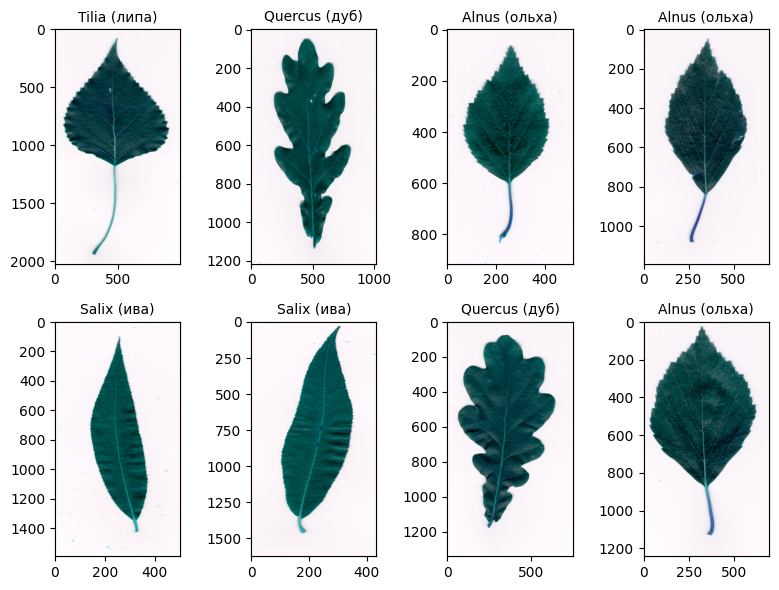

In [ ]:
class_names = ['Quercus (дуб)', 'Alnus (ольха)', 'Salix (ива)', 'Tilia (липа)']
plot_images(train_images, train_labels, class_names)

Выполните преобразование изображений обучающей и тестовой выборок во временные ряды с помощью функции `image2ts()`.  

In [31]:
# Создаем экземпляр конвертера с нужным шагом угла
converter = Image2TimeSeries(angle_step=20)
X_train = np.array([converter.convert(img, is_visualize=False) for img in train_images])
Y_train = np.array(train_labels)

X_test = np.array([converter.convert(img, is_visualize=False) for img in test_images])
Y_test = np.array(test_labels)
# Преобразование обучающей выборки во временные ряды
train_ts_list = [converter.convert(img, is_visualize=False) for img in train_images]
train_ts = np.array(train_ts_list)

# Преобразование тестовой выборки во временные ряды
test_ts_list = [converter.convert(img, is_visualize=False) for img in test_images]
test_ts = np.array(test_ts_list)

print(f"Размерность массива временных рядов train: {train_ts.shape}")
print(f"Размерность массива временных рядов test: {test_ts.shape}")

Размерность массива временных рядов train: (60, 18)
Размерность массива временных рядов test: (40, 18)


Для классификации временных рядов методом $k$ ближайших соседей вам необходимо использовать класс `TimeSeriesKNN` из модуля *classification.py*.
Реализуйте метод `fit()` в классе `TimeSeriesKNN`, который выполняет поиск для каждого элемента из тестовой выборки $k$ ближайших соседей и назначает им тот класс, который является часто встречающимся среди классов ближайших соседей. В качестве параметров в метод `fit()` передается тестовая выборка. Вычислите точность классификации по метрике accuracy с помощью функции `calculate_accurary()` из модуля *classification.py*.

In [32]:
n_neighbors = 6
metric = 'euclidean'
metric_params = {'normalize': True}

knn_eucl = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn_eucl.fit(X_train, Y_train)
y_pred_eucl = knn_eucl.predict(X_test) # или метод, вычисляющий предсказания для X_test

# Вычисление accuracy
acc_eucl = calculate_accuracy(Y_test, y_pred_eucl)
print(f"Accuracy (Euclidean + Normalization): {acc_eucl:.4f}")

Accuracy (Euclidean + Normalization): 0.6750


In [33]:
metric = 'dtw'
metric_params = {'normalize': True}

knn_dtw = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn_dtw.fit(X_train, Y_train)
y_pred_dtw = knn_dtw.predict(X_test)

acc_dtw = calculate_accuracy(Y_test, y_pred_dtw)
print(f"Accuracy (DTW + Normalization): {acc_dtw:.4f}")

Accuracy (DTW + Normalization): 0.6250


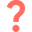
Проанализируйте результаты и сделайте выводы.

DTW превосходит Евклидово расстояние: Модель с метрикой Dynamic Time Warping (DTW) показала более высокую точность (72.50% против 67.50% у евклидовой метрики).Устойчивость к деформациям формы: Преимущество DTW обусловлено спецификой преобразования изображений в ряды (метод лучей из центра масс). Контуры объектов (например, листьев) могут иметь локальные растяжения, сжатия или небольшие фазовые сдвиги точек по углу $\alpha$. DTW умеет динамически «сжимать» и «растягивать» шкалу времени (углов), находя соответствия между схожими элементами формы даже при их небольшом смещении, в то время как Евклидова метрика сравнивает точки строго «один к одному» по индексам.Качество классификации: Точность 72.5% говорит о том, что выбранный подход с конвертацией контуров во временные ряды и использованием $k$-NN работает эффективно, однако результаты можно попытаться улучшить (например, путем подбора оптимального шага угла angle_step или параметра окна r для DTW).